# Introduction

Context: 
- A fast food chain wants to choose one of three new marketing campaigns to advertise a new menu item. To do this, different promotions are used at each location for which the new item is included in the menu. This is done over four weeks, where weekly sales are recorded at each respective location. 

Goal: 
- Determine which marketing campaign is best through statistical testing.

Intended audience: 
- Marketing managers for this fast food chain would benefit from this analysis, as it will provide them with data to help make a decision for choosing the best marketing campaign. 

Target metric: 
- The target metric used here is the _SalesInThousands_ variables, which shows the total weekly sales in dollars for a given location and promotion. 

Project Flow: 
- Introduction
- Importing necessary libraries
- Data loading
- Exploratory Data Analysis 
- Assumptions Checking
- A/B Testing
- Decision



# Importing Libraries and Data Loading

Importing libraries to be used: 

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats
import seaborn as sns
import matplotlib.pylab as plt
import pylab as py
from functions import bootstrap_3means, bootstrap_3medians, plot_cdf_by_group


%matplotlib inline

Taking an initial look at the data: 

In [2]:
ff = pd.read_csv(
    "WA_Marketing-Campaign.csv", sep=","
)
ff


,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81
...,...,...,...,...,...,...,...
543,10,Large,919,2,1,4,64.34
544,10,Large,920,14,2,1,50.20
545,10,Large,920,14,2,2,45.75
546,10,Large,920,14,2,3,44.29


There are 548 total entries here, with 7 variables.

# Initial Data Exploration

To be able to properly perform statistical testing, it is important to examine the data first. The first step is to look at the data types present: 

In [3]:
ff.dtypes

MarketID              int64
MarketSize           object
LocationID            int64
AgeOfStore            int64
Promotion             int64
week                  int64
SalesInThousands    float64
dtype: object

Most of the variables are numberical, with the MarketSize variable being an object. Next, checking to see if there are any missing values: 

In [4]:
ff.isnull().any()

MarketID            False
MarketSize          False
LocationID          False
AgeOfStore          False
Promotion           False
week                False
SalesInThousands    False
dtype: bool

There are no missing values. Now, are there any duplicate entries?

In [5]:
ff.duplicated().any()

np.False_

No duplicate rows. Now, variables can be explored one by one: 

# Variable Exploration

## Week

Looking at the counts of the week variable gives: 

In [6]:
week_df = ff["week"].value_counts().sort_index().rename_axis("week").to_frame("Counts")
week_df

,Counts
week,
1,137
2,137
3,137
4,137


As expected, the test runs for four weeks. Logically, each week should have the same number of counts, which represents the number of stores that participated in the new product launch.

In [7]:
week_df.sum()

Counts    548
dtype: int64

It looks like there were 137 stores that participated in this study, with total data points being 548.

Next, looking at the location ID variable frequencies: 

## Location ID

In [8]:
location_id = ff["LocationID"].value_counts().rename_axis("LocationID").to_frame("Counts")
total_locations = location_id["Counts"].sum()
location_id

,Counts
LocationID,
1,4
615,4
609,4
610,4
611,4
...,...
222,4
221,4
220,4


It seems as though each store is associated with its unique location ID, which is an integer and can range from 1 to 920. This variable does not seem particularly useful for this analysis, as the objective is to discover the promotion type with the highest sales. 

Next, looking at the market ID variable frequencies: 

## Market ID

In [9]:
market_id = ff["MarketID"].value_counts().rename_axis("MarketID").to_frame("Counts")
market_id

,Counts
MarketID,
3,88
10,80
5,60
6,60
7,60
1,52
8,48
9,40
4,36


There seem to be 10 different markets that participated in this experiment. This variable is also not important for statistical testing as it is not related to product sales.

Next, looking at the promotion variable:

## Promotion

In [10]:
promotions = ff["Promotion"].value_counts().rename_axis("Promotion").to_frame("Counts")
promotions

,Counts
Promotion,
3,188
2,188
1,172


As the sample size of each promotion is not the same, it will be necessary to check for sample ratio mismatch (SRM). This can be done with a chi-squared test. If there were the same number of samples in each group, this number would be: 

In [11]:
exp_num = (promotions.sum()) / len(promotions)
exp_num.round(0)

Counts    183.0
dtype: float64

In [12]:
s = [promotions["Counts"].iloc[_] for _ in range(len(promotions))]
n = len(s)
exp_size = [(np.sum(s) / n) for _ in range(n)]
chi = stats.chisquare(s, exp_size)
if chi[1] < 0.01:
    print("SRM warning")
else:
    print("Probably no SRM")

Probably no SRM


As this test shows no likely SRM, A/B testing will likely give reliable results.

Next, examining market size: 

## Market Size

In [13]:
market_size = ff["MarketSize"].value_counts().rename_axis("MarketSize").to_frame("Counts")
total_markets = market_size["Counts"].sum()
market_size["Percentage"] = market_size["Counts"].apply(
    lambda x: x / total_markets * 100
)
market_size

,Counts,Percentage
MarketSize,,
Medium,320,58.394161
Large,168,30.656934
Small,60,10.948905


Most markets are medium sized, and only 11% of markets here are small. This could be a variable to consider in case of difficulty drawing conclusions about the total sales for a given promotion because the size of a market could influence the number of sales of a product for a given promotion. 

### Market Size by Promotion

To understand how promotions are distributed across different market sizes, it is helpful to look at their joint frequency table.

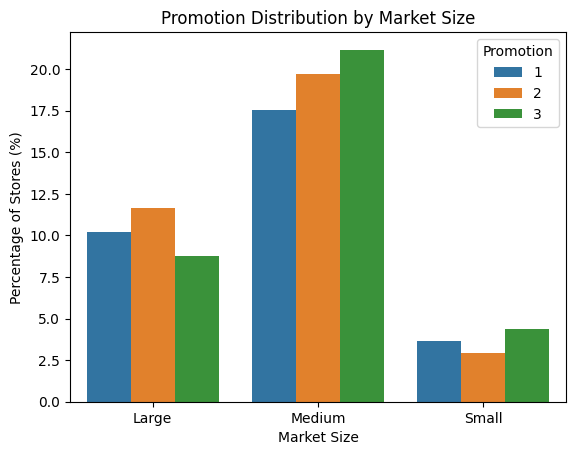

In [14]:
market_promo_counts = (
    ff.groupby(["MarketSize", "Promotion"])["SalesInThousands"]
    .count()
    .rename("Counts")
    .reset_index()
)
total_counts = market_promo_counts["Counts"].sum()
market_promo_counts["Percentage"] = market_promo_counts["Counts"].apply(
    lambda x: x / total_counts * 100
)
sns.barplot(
    data=market_promo_counts,
    x="MarketSize",
    y="Percentage",
    hue="Promotion",
    palette="tab10",
).set(
    title="Promotion Distribution by Market Size",
    ylabel="Percentage of Stores (%)",
    xlabel="Market Size",
);

All promotions seem to be equally distributed between stores of each market size, and no clear trends are seen between promotion number and maket size. Market size is unlikely to explain sales difference between promotions.

## Age of Store: 

Looking at the age of stores: 

In [15]:
store_age = ff["AgeOfStore"].value_counts().rename_axis("AgeOfStore").to_frame("Counts")
total_stores = store_age["Counts"].sum()
store_age["Percentage"] = store_age["Counts"].apply(lambda x: x / total_stores * 100)
store_age.head()

,Counts,Percentage
AgeOfStore,,
1,80,14.598540
4,44,8.029197
5,44,8.029197
7,40,7.299270
8,40,7.299270


Looking at the description of this variable to understand general store ages: 

In [16]:
ff["AgeOfStore"].describe()

count    548.000000
mean       8.503650
std        6.638345
min        1.000000
25%        4.000000
50%        7.000000
75%       12.000000
max       28.000000
Name: AgeOfStore, dtype: float64

Stores range from 1 to 28 years old, with 50% of them being between 4 and 12 years old. About 15% of stores are one year old only. It would help to visualize this data in a bar chart: 

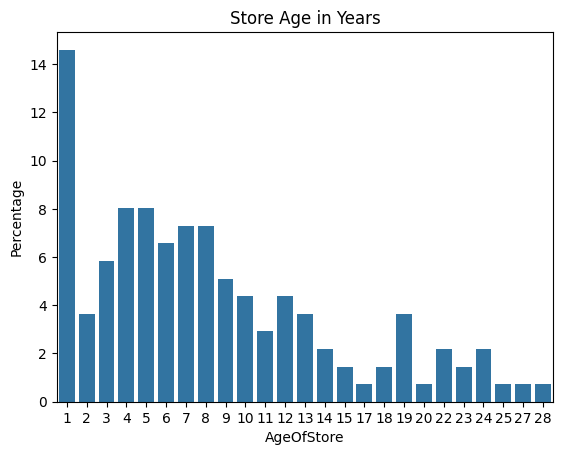

In [17]:
sns.barplot(data=store_age, x="AgeOfStore", y="Percentage").set(
    title="Store Age in Years"
);

This chart also shows that most stores are quite young (only one year old). After 5 years, a decreasing percentage of stores is present. This variable is not entirely relevant to statistical testing for promotion success. However, older stores could have a more reliable customer base with more stable sales over time.

Next, it is important to look at the counts for each promotion type to check for a sample ratio mismatch: 

## Sales in Thousands

Looking at elementary statistics of this variable with a frequency chart can help to understand its distribution: 

In [18]:
ff["SalesInThousands"].describe()

count    548.000000
mean      53.466204
std       16.755216
min       17.340000
25%       42.545000
50%       50.200000
75%       60.477500
max       99.650000
Name: SalesInThousands, dtype: float64

Visualizing the sales: 


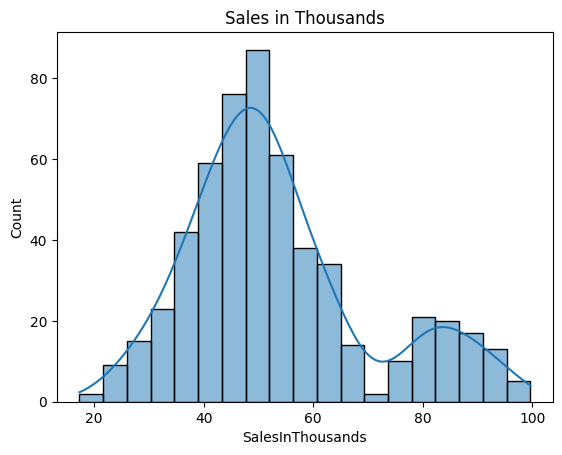

In [19]:
sns.histplot(data=ff, x="SalesInThousands", kde=True).set(title="Sales in Thousands");

It looks like this is a bimodal distribution with half of sales being between 42 and 60 thousand dollars. In total, the sales vary between 17 and 99 thousand dollars. Some outliers have abnormally large sales (over about 70 thousand dollars).

Grouping the total sales by promotion type will give a general idea of promotion performance: 

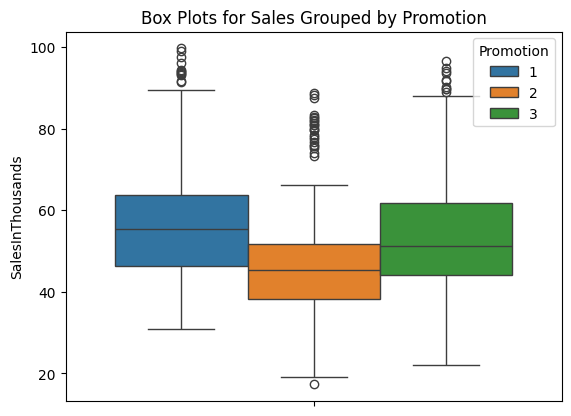

In [20]:
sns.boxplot(data=ff, hue="Promotion", y="SalesInThousands", palette="tab10").set(
    title="Box Plots for Sales Grouped by Promotion"
);

From the box plots, each distribution seems to have the same bimodal shape. The outliers here, with over about 70 thousand dollars in weekly sales, could be due to store age, location, or market size and will be kept as part of the data. 

Looking at sales per promotion type over the four weeks of data collection gives:

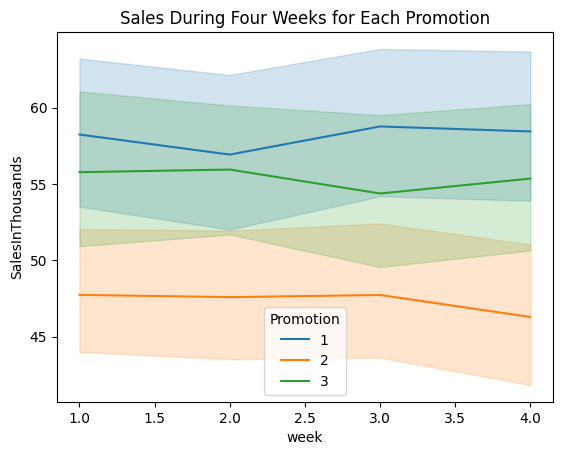

In [21]:
sns.lineplot(
    data=ff, x="week", y="SalesInThousands", hue="Promotion", palette="tab10"
).set(title="Sales During Four Weeks for Each Promotion");

From this graph and from the box plots, it seems that promotion 1 and 3 had the most success over the four week period. in addition, promotion 1 and promotion 3's sales seem to go in opposite directions: from week 2-3, promotion 1's sales increase while promotion 3's sales decrease. During the last week of data collection, it is only promotion 3 that increases. 

In addition, as the distributions seem to be bimodal, it is likely that tests that assume normality (for example, student t-test) will not be used here.

### Weekly Sales by Promotion

Since the target metric is weekly sales, and promotion 2's average sales are consistently lower than the other promotions average sales, examining weekly sales relative to sales in week 2 could be interesting: 

In [22]:
weekly_sales_promo = (
    ff.groupby(["Promotion", "week"])["SalesInThousands"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "MeanSales", "count": "NumStores"})
    .reset_index()
)

Setting promotion 2 as the baseline: 

[Text(0.5, 1.0, 'Relative Weekly Sales vs Promotion 2'),
 Text(0.5, 0, 'Week'),
 Text(0, 0.5, '% Difference in Mean Sales vs Promotion 2')]

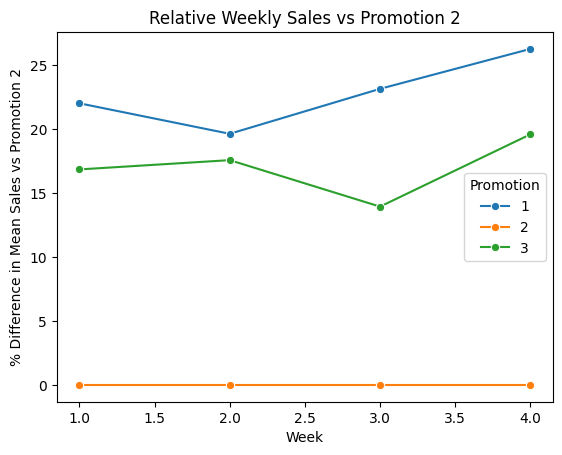

In [ ]:
baseline = (
    weekly_sales_promo[weekly_sales_promo["Promotion"] == 2]
    .loc[:, ["week", "MeanSales"]]
    .rename(columns={"MeanSales": "BaselineMean"})
)

weekly_rel = weekly_sales_promo.merge(baseline, on="week")
weekly_rel["PctDiff_vs_P2"] = (
    (weekly_rel["MeanSales"] / weekly_rel["BaselineMean"] - 1) * 100
)

plot_data = weekly_rel[weekly_rel["Promotion"] != 2]


sns.lineplot(
    data=weekly_rel,    
    x="week",
    y="PctDiff_vs_P2",
    hue="Promotion",
    marker="o",
    palette="tab10",
).set(
    title="Relative Weekly Sales vs Promotion 2",
    xlabel="Week",
    ylabel="% Difference in Mean Sales vs Promotion 2",
)

This plot shows that both promotion 1 and 3's average weekly sales are consistently 15-25% higher than promotion 2's weekly sales. Promotion 1 also consistently has the highest mean sales through each week. This will be statistically verified in the following sections. 

# Normality assumption 

In order to perform statistical tests to help with A/B testing, it is necessary to look at the normality of the data. This will help to choose which tests are performed.

A quantile-quantile plot can help to show if this data is normally distributed: 

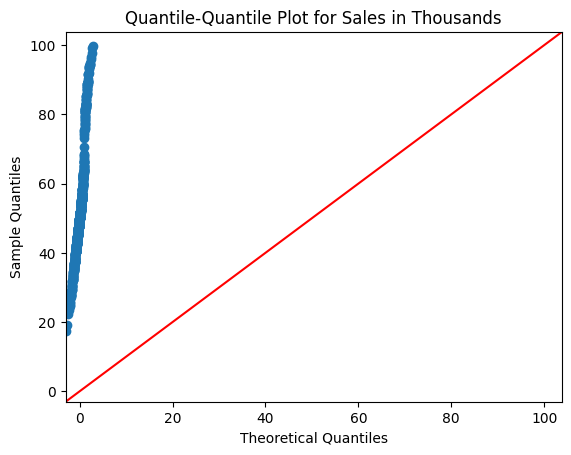

In [24]:
sm.qqplot(ff["SalesInThousands"], line="45")
plt.title("Quantile-Quantile Plot for Sales in Thousands")
py.show()

This data does not look normal at all, as it does not follow a straight line here. This is no surprise, as the histogram of the data also did not show normality.

In addition, a Kolmogorov-Smirnov test at the 95% confidence level could show the non-normality of this data. Here, the null hypothesis is that the distribution is normal and the alternative hypothesis is that the distribution is not normal. 

In [25]:
stat, pval = stats.kstest(ff["SalesInThousands"], "norm")
print(f"p value: ", pval)
if pval < 0.05:
    print(
        "According to the Kolmogorov-Smirnov test, this distribution cannot be assumed to be normal."
    )
else:
    print("Normality can be assumed.")

p value:  0.0
According to the Kolmogorov-Smirnov test, this distribution cannot be assumed to be normal.


As the p value from this test is zero, this again shows that the game rounds variable does not follow a normal distribution. 

Now, the data could be transformed using a Box Cox transformation to see this induces normality. This could be helpful in order to perform statistical tests that assume normality, such as the student t test. 

In [26]:
fitted_data, fitted_lambda = stats.boxcox(ff["SalesInThousands"] + 1)

print(f"Lambda value used for Transformation: {fitted_lambda}")

Lambda value used for Transformation: -0.0013957368742750734


Visualizing this transformation gives: 

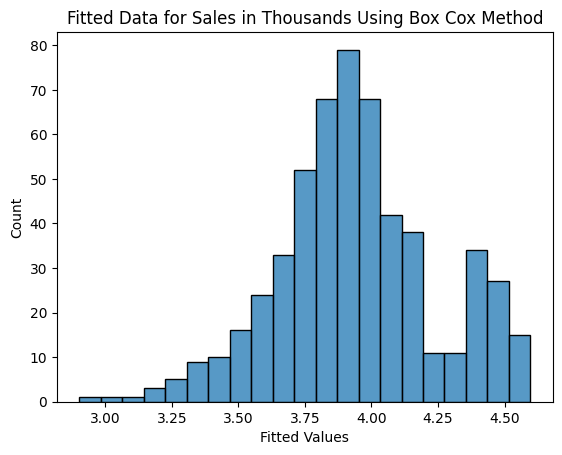

In [27]:
sns.histplot(fitted_data).set(
    title="Fitted Data for Sales in Thousands Using Box Cox Method",
    xlabel="Fitted Values",
);

This data still does not look quite normally distributed. Looking at a QQ plot will show this more clearly: 

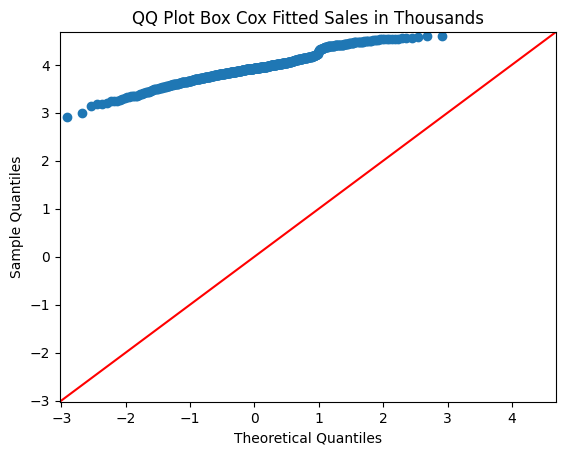

In [28]:
sm.qqplot(fitted_data, line="45")
plt.title("QQ Plot Box Cox Fitted Sales in Thousands")
py.show()

From the histogram and the QQ plot, it seems that the Box Cox transformation has not induced normality in the distribution. Performing a Kolmogorov-Smirnov test, where the null hypothesis assumes normality and the alternative hypothesis is that the data is not a normal distribution gives: 

In [29]:
stats.kstest(fitted_data, "norm")
print(f"p value: ", pval)
if pval < 0.05:
    print(
        "According to the Kolmogorov-Smirnov test, this distribution cannot be assumed to be normal."
    )
else:
    print("Normality can be assumed.")

p value:  0.0
According to the Kolmogorov-Smirnov test, this distribution cannot be assumed to be normal.


This data is still not normally distributed, even after the Box Cox transformation. Therefore, non parametric tests will be used for analysis.

# A/B Testing

Non-parametric tests that are performed: 
- Bootstrapping for means
- Bootstrapping for medians
- Kolmogorov-Smirnov Test

## Bootstrapping for Means

Using bootstrapping means that no underlying assumptions are made about the data. Here, n_iterations is the number of iterations for resampling. Then, bootstrapping is used to obtain the mean distribution and a 95% confidence interval is calculated. To do this, the difference between means is first calculated in the obs_diff variables: 

In [30]:
p1_sales = ff[ff["Promotion"] == 1]
p2_sales = ff[ff["Promotion"] == 2]
p3_sales = ff[ff["Promotion"] == 3]

obs_diff_12 = np.mean(p1_sales["SalesInThousands"]) - np.mean(
    p2_sales["SalesInThousands"]
)
obs_diff_13 = np.mean(p1_sales["SalesInThousands"]) - np.mean(
    p3_sales["SalesInThousands"]
)
obs_diff_23 = np.mean(p2_sales["SalesInThousands"]) - np.mean(
    p3_sales["SalesInThousands"]
)

n_iterations = 10000

boot_diffs_12, boot_diffs_13, boot_diffs_23 = bootstrap_3means(
    p1_sales["SalesInThousands"],
    p2_sales["SalesInThousands"],
    p3_sales["SalesInThousands"],
    n_iterations,
)

conf_int_12 = np.percentile(boot_diffs_12, [2.5, 97.5])
conf_int_13 = np.percentile(boot_diffs_13, [2.5, 97.5])
conf_int_23 = np.percentile(boot_diffs_23, [2.5, 97.5])

print("Observed Difference 1 vs 2:", obs_diff_12)
print("Observed Difference 1 vs 3:", obs_diff_13)
print("Observed Difference 2 vs 3:", obs_diff_23)

print("\n95% Confidence Intervals:")
print("Confidence interval 1 and 2:", conf_int_12)
print("Confidence interval 1 and 3:", conf_int_13)
print("Confidence interval 2 and 3:", conf_int_23)

Observed Difference 1 vs 2: 10.76959673428997
Observed Difference 1 vs 3: 2.734543542800594
Observed Difference 2 vs 3: -8.035053191489375

95% Confidence Intervals:
Confidence interval 1 and 2: [ 7.48125959 14.08090441]
Confidence interval 1 and 3: [-0.78105774  6.19008906]
Confidence interval 2 and 3: [-11.24402793  -4.80545878]


Next, these bootstrapped differences in sales for each promotion can be plotted: 

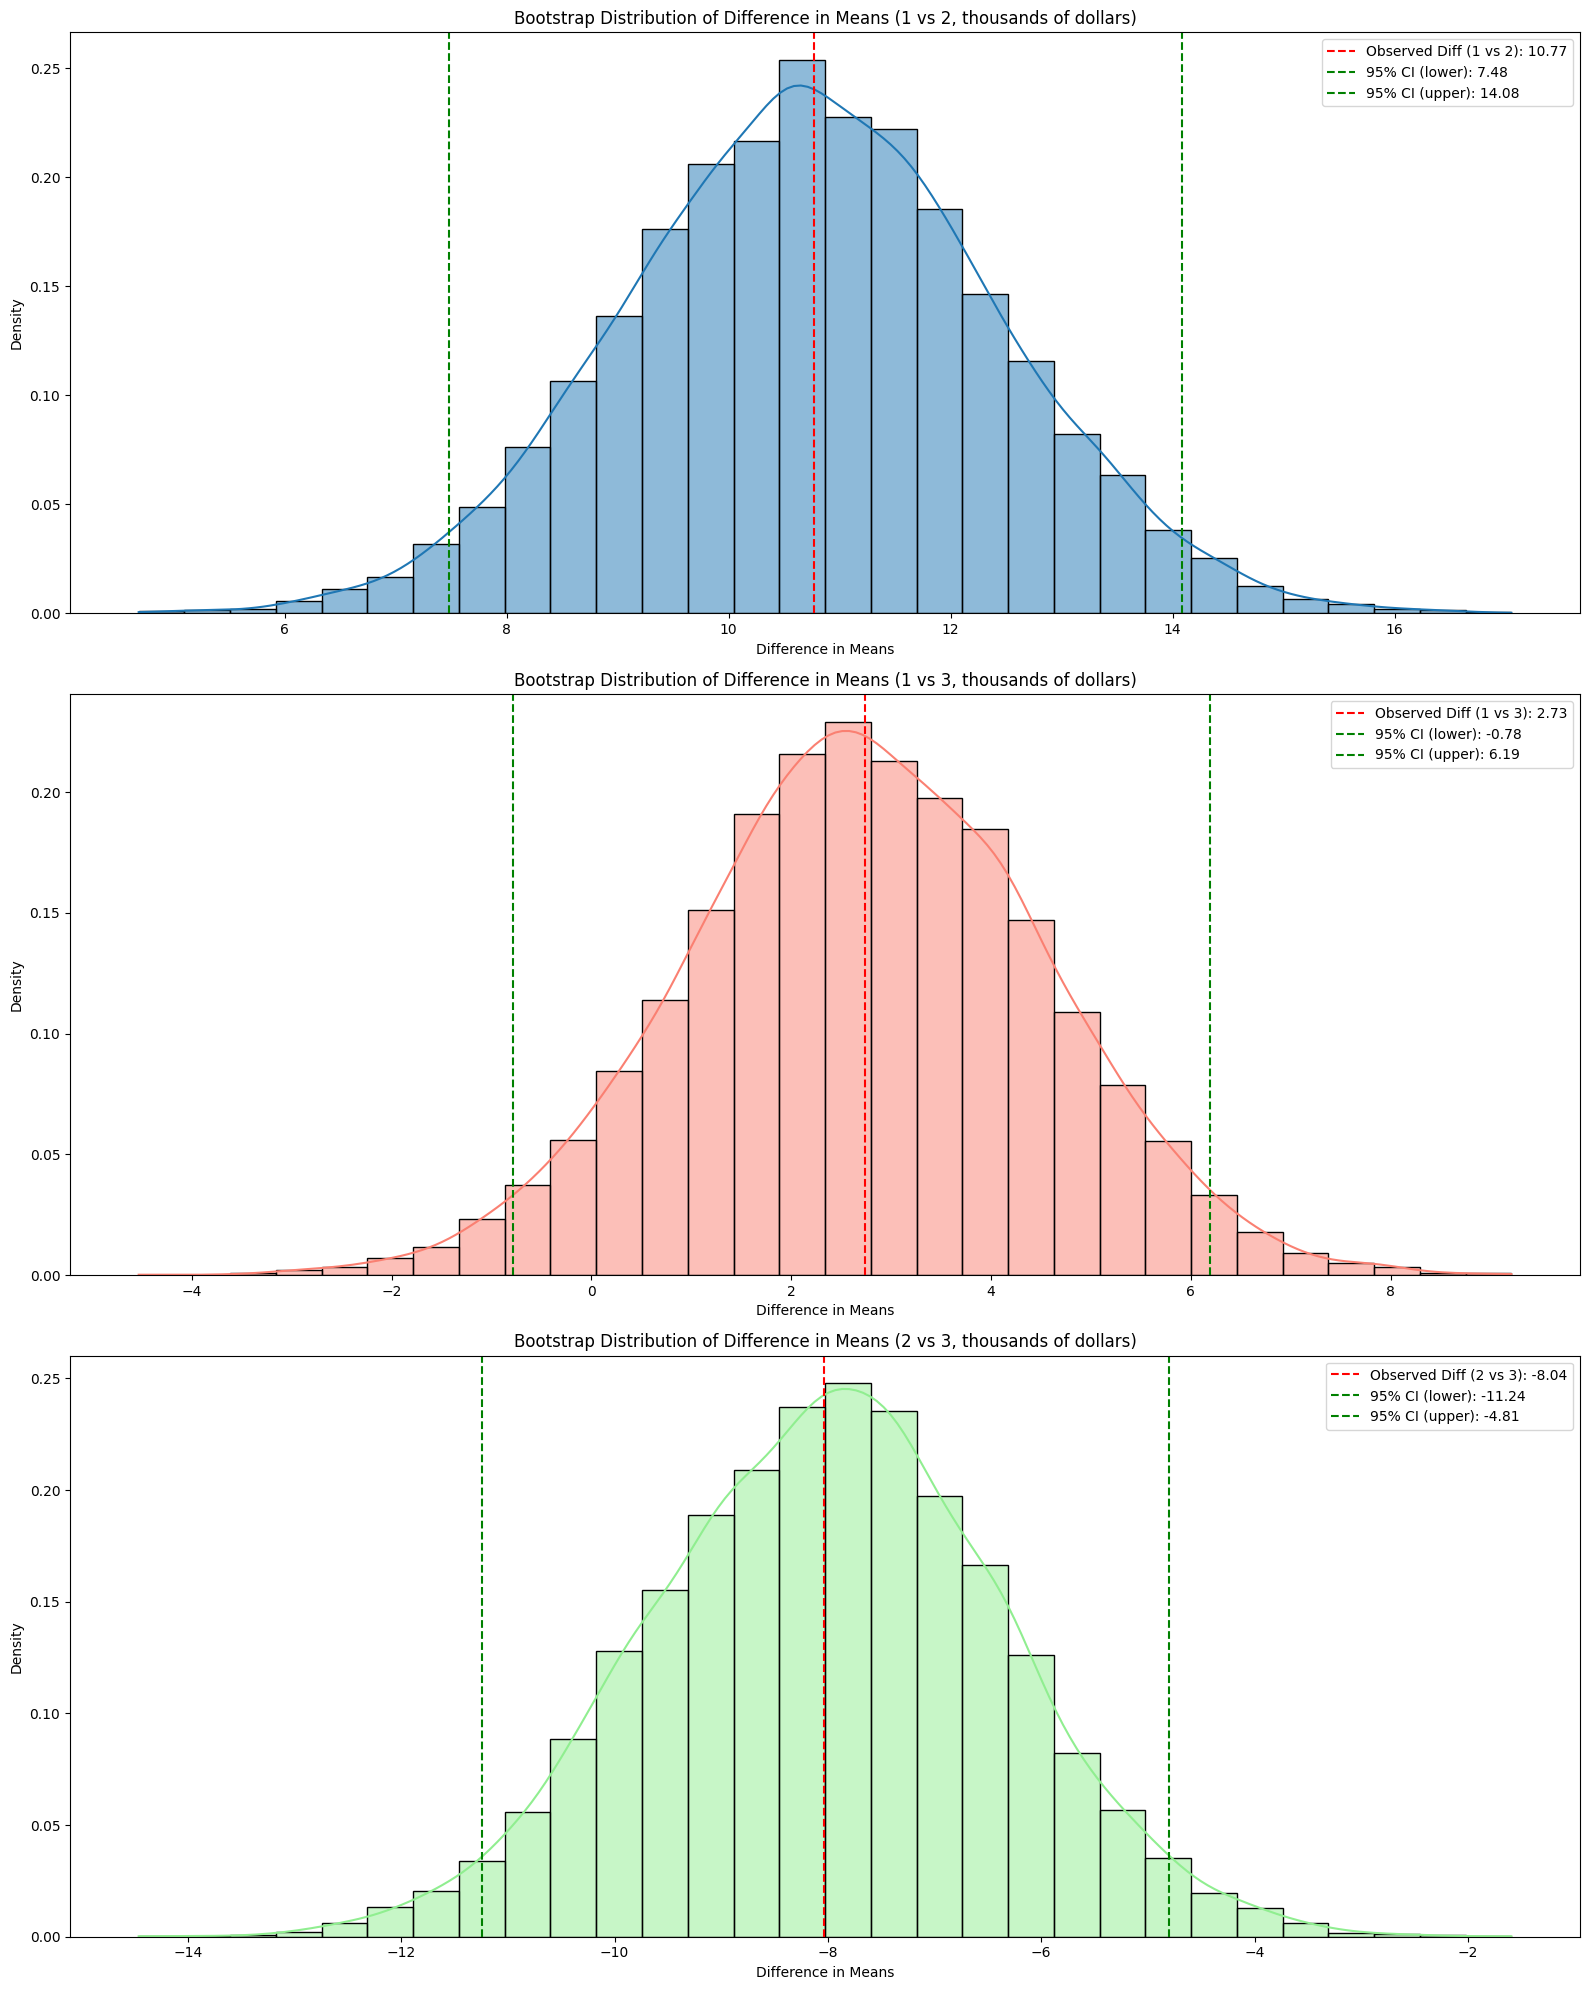

In [31]:
plt.figure(figsize=(16, 20))

# 1 vs 2
plt.subplot(3, 1, 1)
sns.histplot(boot_diffs_12, kde=True, bins=30, stat="density")
plt.axvline(
    x=obs_diff_12,
    color="red",
    linestyle="--",
    label=f"Observed Diff (1 vs 2): {obs_diff_12:.2f}",
)
plt.axvline(
    x=conf_int_12[0],
    color="green",
    linestyle="--",
    label=f"95% CI (lower): {conf_int_12[0]:.2f}",
)
plt.axvline(
    x=conf_int_12[1],
    color="green",
    linestyle="--",
    label=f"95% CI (upper): {conf_int_12[1]:.2f}",
)
plt.title(
    "Bootstrap Distribution of Difference in Means (1 vs 2, thousands of dollars)"
)
plt.xlabel("Difference in Means")
plt.ylabel("Density")
plt.legend()

# 1 vs 3
plt.subplot(3, 1, 2)
sns.histplot(boot_diffs_13, kde=True, color="salmon", bins=30, stat="density")
plt.axvline(
    x=obs_diff_13,
    color="red",
    linestyle="--",
    label=f"Observed Diff (1 vs 3): {obs_diff_13:.2f}",
)
plt.axvline(
    x=conf_int_13[0],
    color="green",
    linestyle="--",
    label=f"95% CI (lower): {conf_int_13[0]:.2f}",
)
plt.axvline(
    x=conf_int_13[1],
    color="green",
    linestyle="--",
    label=f"95% CI (upper): {conf_int_13[1]:.2f}",
)
plt.title(
    "Bootstrap Distribution of Difference in Means (1 vs 3, thousands of dollars)"
)
plt.xlabel("Difference in Means")
plt.ylabel("Density")
plt.legend()

# 2 vs 3
plt.subplot(3, 1, 3)
sns.histplot(boot_diffs_23, kde=True, color="lightgreen", bins=30, stat="density")
plt.axvline(
    x=obs_diff_23,
    color="red",
    linestyle="--",
    label=f"Observed Diff (2 vs 3): {obs_diff_23:.2f}",
)
plt.axvline(
    x=conf_int_23[0],
    color="green",
    linestyle="--",
    label=f"95% CI (lower): {conf_int_23[0]:.2f}",
)
plt.axvline(
    x=conf_int_23[1],
    color="green",
    linestyle="--",
    label=f"95% CI (upper): {conf_int_23[1]:.2f}",
)
plt.title(
    "Bootstrap Distribution of Difference in Means (2 vs 3, thousands of dollars)"
)
plt.xlabel("Difference in Means")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

These histograms show that promotion one in general has larger mean sales than promotion 2. The mean sales cannot be exactly distinguished between promotion 1 and 3, and the last graph shows that promotion 3 has larger average sales than promotion 2. It is possible to see that bootstrapping for means does give a normal shaped distribution.

Comparing boxplots of these differences on the same graph shows the same trend side by side:

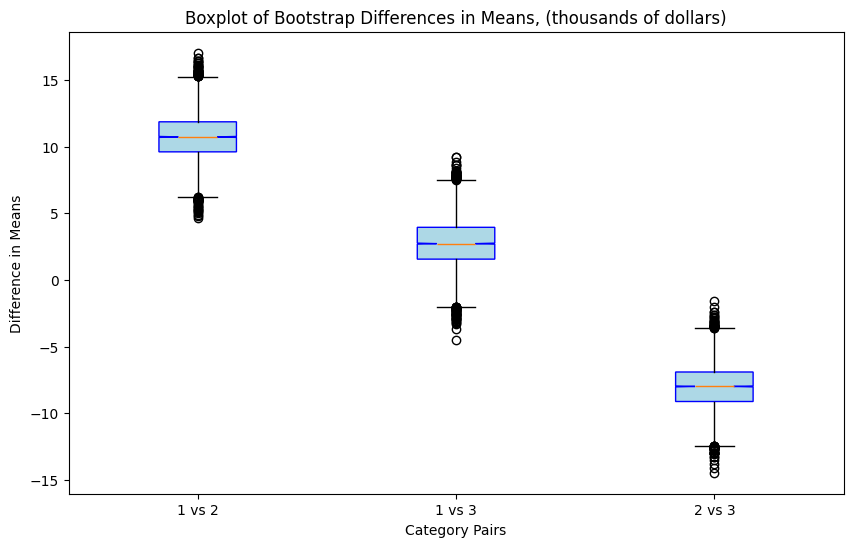

In [32]:
plt.figure(figsize=(10, 6))

bootstrap_diffs = [boot_diffs_12, boot_diffs_13, boot_diffs_23]
labels = ["1 vs 2", "1 vs 3", "2 vs 3"]

plt.boxplot(
    bootstrap_diffs,
    tick_labels=labels,
    notch=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
)

plt.title("Boxplot of Bootstrap Differences in Means, (thousands of dollars)")
plt.ylabel("Difference in Means")
plt.xlabel("Category Pairs")
plt.show()

## Bootstrapping for Medians

Bootstrapping is also used here to evaluate differences between medians in the three groups. This technique is used to give more robust conclusions to the first bootstrapping method. Here, the mean_obs_diff variable is the difference between medians, and n_iterations is the number of iterations to do. Then, a 95% confidence interval is calculated: 

In [33]:
med_obs_diff_12 = np.median(p1_sales["SalesInThousands"]) - np.median(
    p2_sales["SalesInThousands"]
)
med_obs_diff_13 = np.median(p1_sales["SalesInThousands"]) - np.median(
    p3_sales["SalesInThousands"]
)
med_obs_diff_23 = np.median(p2_sales["SalesInThousands"]) - np.median(
    p3_sales["SalesInThousands"]
)

n_iterations = 10000

med_boot_diffs_12, med_boot_diffs_13, med_boot_diffs_23 = bootstrap_3medians(
    p1_sales["SalesInThousands"],
    p2_sales["SalesInThousands"],
    p3_sales["SalesInThousands"],
    n_iterations,
)

med_conf_int_12 = np.percentile(med_boot_diffs_12, [2.5, 97.5])
med_conf_int_13 = np.percentile(med_boot_diffs_13, [2.5, 97.5])
med_conf_int_23 = np.percentile(med_boot_diffs_23, [2.5, 97.5])

print("Observed Difference 1 vs 2:", med_obs_diff_12)
print("Observed Difference 1 vs 3:", med_obs_diff_13)
print("Observed Difference 2 vs 3:", med_obs_diff_23)

print("\n95% Confidence Intervals:")
print("Confidence interval 1 and 2:", med_conf_int_12)
print("Confidence interval 1 and 3:", med_conf_int_13)
print("Confidence interval 2 and 3:", med_conf_int_23)

Observed Difference 1 vs 2: 10.0
Observed Difference 1 vs 3: 4.220000000000006
Observed Difference 2 vs 3: -5.779999999999994

95% Confidence Intervals:
Confidence interval 1 and 2: [ 7.284625 12.400125]
Confidence interval 1 and 3: [1.534875 6.585125]
Confidence interval 2 and 3: [-8.05  -3.505]


As none of these confidence intervals include zero, it is likely that all three promotion types have different median values. Looking at this in a plot gives: 


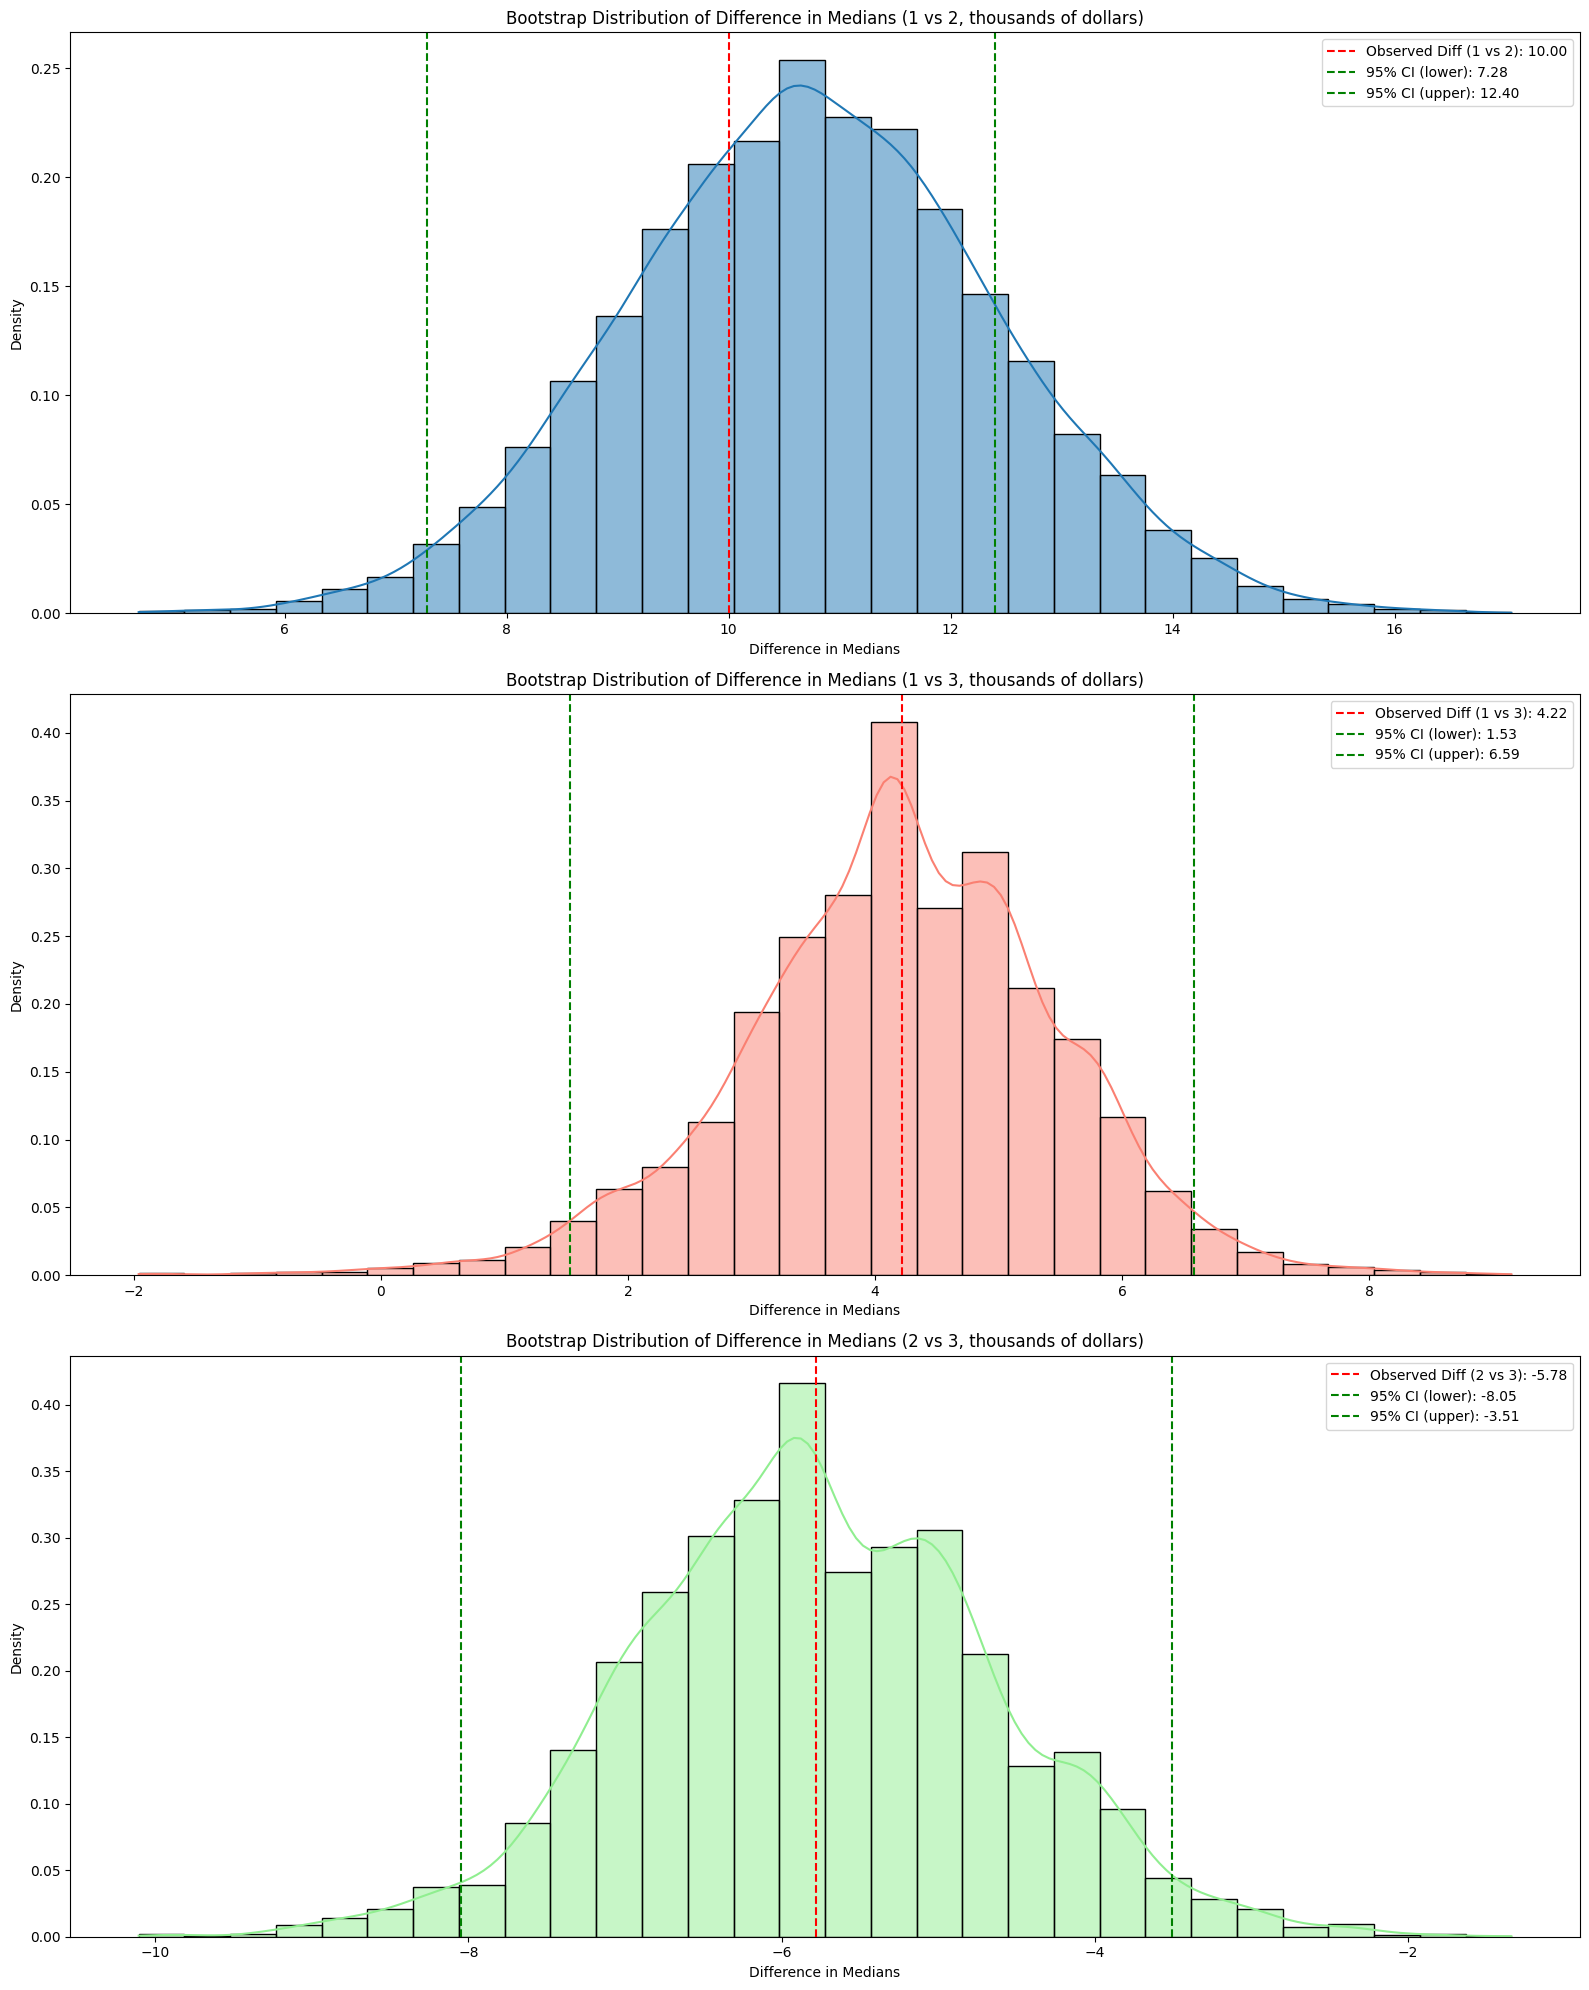

In [34]:
plt.figure(figsize=(16, 20))

# 1 vs 2
plt.subplot(3, 1, 1)
sns.histplot(boot_diffs_12, kde=True, bins=30, stat="density")
plt.axvline(
    x=med_obs_diff_12,
    color="red",
    linestyle="--",
    label=f"Observed Diff (1 vs 2): {med_obs_diff_12:.2f}",
)
plt.axvline(
    x=med_conf_int_12[0],
    color="green",
    linestyle="--",
    label=f"95% CI (lower): {med_conf_int_12[0]:.2f}",
)
plt.axvline(
    x=med_conf_int_12[1],
    color="green",
    linestyle="--",
    label=f"95% CI (upper): {med_conf_int_12[1]:.2f}",
)
plt.title(
    "Bootstrap Distribution of Difference in Medians (1 vs 2, thousands of dollars)"
)
plt.xlabel("Difference in Medians")
plt.ylabel("Density")
plt.legend()

# 1 vs 3
plt.subplot(3, 1, 2)
sns.histplot(med_boot_diffs_13, kde=True, color="salmon", bins=30, stat="density")
plt.axvline(
    x=med_obs_diff_13,
    color="red",
    linestyle="--",
    label=f"Observed Diff (1 vs 3): {med_obs_diff_13:.2f}",
)
plt.axvline(
    x=med_conf_int_13[0],
    color="green",
    linestyle="--",
    label=f"95% CI (lower): {med_conf_int_13[0]:.2f}",
)
plt.axvline(
    x=med_conf_int_13[1],
    color="green",
    linestyle="--",
    label=f"95% CI (upper): {med_conf_int_13[1]:.2f}",
)
plt.title(
    "Bootstrap Distribution of Difference in Medians (1 vs 3, thousands of dollars)"
)
plt.xlabel("Difference in Medians")
plt.ylabel("Density")
plt.legend()

# 2 vs 3
plt.subplot(3, 1, 3)
sns.histplot(med_boot_diffs_23, kde=True, color="lightgreen", bins=30, stat="density")
plt.axvline(
    x=med_obs_diff_23,
    color="red",
    linestyle="--",
    label=f"Observed Diff (2 vs 3): {med_obs_diff_23:.2f}",
)
plt.axvline(
    x=med_conf_int_23[0],
    color="green",
    linestyle="--",
    label=f"95% CI (lower): {med_conf_int_23[0]:.2f}",
)
plt.axvline(
    x=med_conf_int_23[1],
    color="green",
    linestyle="--",
    label=f"95% CI (upper): {med_conf_int_23[1]:.2f}",
)
plt.title(
    "Bootstrap Distribution of Difference in Medians (2 vs 3, thousands of dollars)"
)
plt.xlabel("Difference in Medians")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

In general, the bootstrapped median distributions are also normally shaped. The green dotted lines in these histograms show the confidence intervals, and the red dotted line shows the observed difference in medians. The first histogram shows that the median difference between the sales in promotion 1 and 2 are between about 7 and 12 thousand dollars over four weeks, with promotion 1 being higher than promotion 2. 

The second histogram shows that the median difference between the sales for promotion 1 and 3 are between about 2-6 thousand dollars, with promotion 1 having the higher median sales. 

The third histogram shows that the difference between sales for promotion 2 and 3 is approximately between 3 and 8 thousand dollars, with promotion 3 having higher sales than promotion 2.

This can also be shown when comparing boxplots for the three differences: 


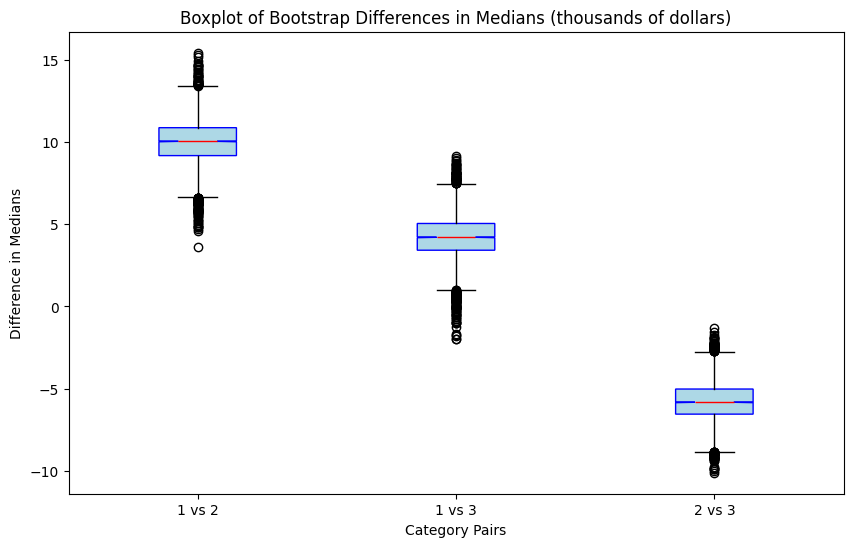

In [35]:
plt.figure(figsize=(10, 6))

med_bootstrap_diffs = [med_boot_diffs_12, med_boot_diffs_13, med_boot_diffs_23]
labels = ["1 vs 2", "1 vs 3", "2 vs 3"]

plt.boxplot(
    med_bootstrap_diffs,
    tick_labels=labels,
    notch=True,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="blue"),
    medianprops=dict(color="red"),
)
plt.title("Boxplot of Bootstrap Differences in Medians (thousands of dollars)")
plt.ylabel("Difference in Medians")
plt.xlabel("Category Pairs")
plt.show()

This boxplot shows essentially the same thing as the previous histograms: the median difference is highest between promotions 1 and 2 and lowest between promotions 1 and 3. It seems that promotion 1 is the most lucrative promotion, followed by promotion 3 and tailed by promotion 2.

## Kolmogorov-Smirnov Test

This is a non parametric test to see if the two samples could be from the same distribution or not, and is used here to corroborate findings from the bootstrapped distributions. 

This test will help to indicate if there is a significant difference in the sales between each promotion type when compared in pairs. Here, the 95% confidence level is used. For each promotion type, the first test's null hypothesis states that there is no difference between the two groups, and the alternate hypothesis states that there is a significant difference between the two groups at the 95% confidence level. 

For promotion 1 and 2: 

In [36]:
alpha = 0.05
statistic, p_value = stats.ks_2samp(
    p1_sales["SalesInThousands"], p2_sales["SalesInThousands"]
)
print("p value: ", p_value)
if p_value < alpha:
    print("Reject null hypothesis; there is a significant difference")
else:
    print("Fail to reject the null hypothesis; there is no significant difference")

p value:  1.864932493852513e-11
Reject null hypothesis; there is a significant difference


Now that a significant difference between the two groups has been found, this test will be repeated to discover the larger of the two groups. Therefore, the null hypothesis is that promotion 2 is larger or equal to promotion 1, and the alternate hypothesis is that promotion 1 is larger than promotion 2.

In [37]:
statistic, p_value = stats.ks_2samp(
    p1_sales["SalesInThousands"], p2_sales["SalesInThousands"], alternative="less"
)
print("p value: ", p_value)
if p_value < alpha:
    print("Reject null (p2 >= p1) hypothesis; p2 is smaller than p1")
else:
    print("Fail to reject the null hypothesis; p2 is greater or equal to p1")

p value:  9.324662469261272e-12
Reject null (p2 >= p1) hypothesis; p2 is smaller than p1


This test agrees with the bootstrapped conclusion that in general, the sales from promotion 1 are larger than those from promotion 2.

For promotion 1 and 3, the null hypothesis being that there is no significant different difference between the distributions and the alternate hypothesis being that there is a significant difference at the 95% confidence level between the two groups, the Kolmogorov-Smirnov test gives: 

In [38]:
statistic, p_value = stats.ks_2samp(
    p1_sales["SalesInThousands"], p3_sales["SalesInThousands"]
)
print("p value: ", p_value)
if p_value < alpha:
    print("Reject null hypothesis; there is a significant difference")
else:
    print("Fail to reject the null hypothesis; there is no significant difference")

p value:  0.011745241846539307
Reject null hypothesis; there is a significant difference


Since a significant difference has been established between promotion 1 and promotion 3, the new null hypothesis is that promotion 3 is larger or equal to promotion 1, and the alternative hypothesis is that promotion 3 is smaller than promotion 1.

In [39]:
statistic, p_value = stats.ks_2samp(
    p1_sales["SalesInThousands"], p2_sales["SalesInThousands"], alternative="less"
)
print("p value: ", p_value)
if p_value < alpha:
    print("Reject null (p3 >= p1) hypothesis; p3 is smaller than p1")
else:
    print("Fail to reject the null hypothesis; p3 is greater or equal to p1")

p value:  9.324662469261272e-12
Reject null (p3 >= p1) hypothesis; p3 is smaller than p1


Again, this test agrees with the bootstrapped median test and says that promotion 3 in general has smaller sale values than promotion 1.

For promotion 2 and 3, the null hypothesis remains that there is no significant difference between the two groups and the alternative hypothesis is that there is a significant difference between the two groups. The Kolmogorov-Smirnov test gives: 

In [40]:
statistic, p_value = stats.ks_2samp(
    p2_sales["SalesInThousands"], p3_sales["SalesInThousands"]
)
print("p value: ", p_value)
if p_value < alpha:
    print("Reject null hypothesis; there is a significant difference")
else:
    print("Fail to reject the null hypothesis; there is no significant difference")

p value:  5.0724093490350975e-06
Reject null hypothesis; there is a significant difference


Since a significant difference at the 95% confidence level has been found between the two groups, the new null hypothesis is that promotion 2 is larger or equal to promotion 3, and the alternative hypothesis is that promotion 3 is larger than promotion 2. This gives: 

In [41]:
statistic, p_value = stats.ks_2samp(
    p3_sales["SalesInThousands"], p2_sales["SalesInThousands"], alternative="less"
)
print("p value: ", p_value)
if p_value < alpha:
    print("Reject null (p2 >= p3) hypothesis; p2 is smaller than p3")
else:
    print("Fail to reject the null hypothesis; p2 is greater or equal to p3")

p value:  2.5362046745175483e-06
Reject null (p2 >= p3) hypothesis; p2 is smaller than p3


This test shows that in general, the sales over four weeks from promotion 3 are shifted toward larger values as compared to those from promotion 2.

Examining these insights in a cumulative distribution function plot: 

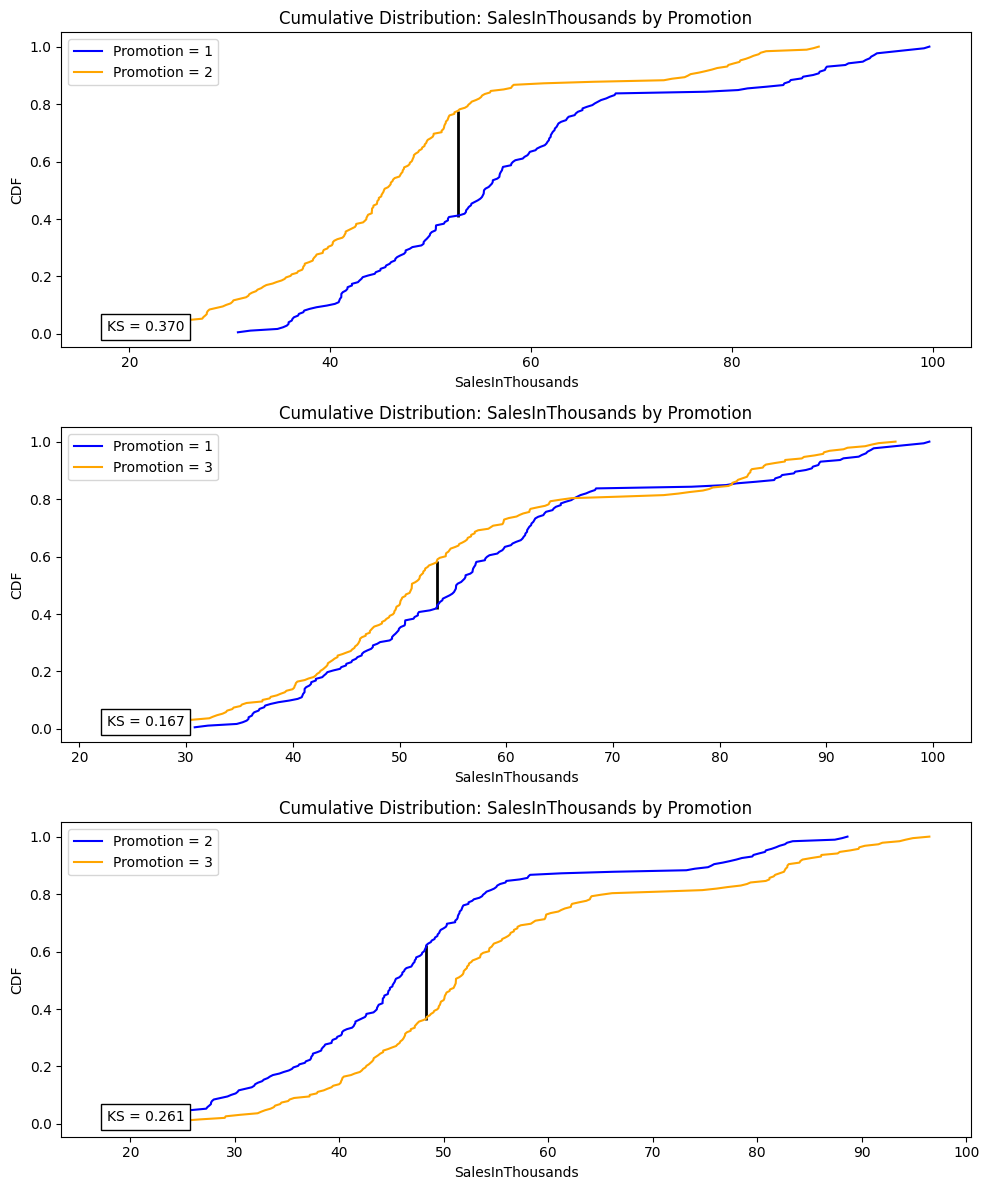

In [42]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
plot_cdf_by_group(
    df=ff,
    value_col="SalesInThousands",
    group_col="Promotion",
    group_a=1,
    group_b=2,
    ax=axes[0],
)

plot_cdf_by_group(
    df=ff,
    value_col="SalesInThousands",
    group_col="Promotion",
    group_a=1,
    group_b=3,
    ax=axes[1],
)

plot_cdf_by_group(
    df=ff,
    value_col="SalesInThousands",
    group_col="Promotion",
    group_a=2,
    group_b=3,
    ax=axes[2],
)


plt.tight_layout()
plt.show()


The top and bottom plot show that promotion 2 tends to have lower sales than promotion 1 and 3, and the middle plot shows that promotion 3 generally has lower sales than promotion 1, though at higher sales values (over 70 thousand, the distribution frequencies for promotion 1 and 3 are quite similar). This agrees with findings from the rest of the project, that the promotion with the highest sales overall is promotion 1.

# Decision and Conclusions

For this dataset, three statistical methods were used to determine differences between three promotion types for number of sales over a four week period: bootstrapping for means, bootstrapping for medians,  and the Kolmogorov-Smirnov test. On average, promotion 1 has about 20% higher weekly sales than promotion 2, and about 5% higher weekly sales than promotion 3. 

Key conclusions are: 
- Bootstrapping for the mean value in each group showed that promotion 2 had lower mean sales than the other two promotions. 
- Bootstrapping for the median value in each group gave the same result as the Kolmogorov-Smirnov test: promotion 2 still was found to have the lowest number of total sales, promotion 1 was found to have the highest sales, and promotion 3 had slightly lower sales than promotion 1. 

In conclusion, from these tests, there is enough evidence to say that promotion 1 has the highest sales over the four week test period. The sales from promotion 3 are the next highest, and the total sales from promotion 2 are the lowest. The data-based suggestion is thus to continue to implement promotion 1 throughout the marketing campaign to maximize sales of this new menu item in the fast food restaurant chain.